In [8]:
import numpy as np
import pandas as pd


# Sample data matrix
data = {
    'lemma': ['bien', 'mal', 'beaucoup', 'peu', 'très', 'trop'],
    'parent=VERB': [54, 69, 64, 37, 7, 21],
    'parent_rel=advmod': [64, 82, 46, 59, 100, 91],
    # 'child=NOUN': [5, 20, 65, 30, 0, 15]
}

df = pd.DataFrame(data)
X = df.drop(columns='lemma').values

IndexError: index 2 is out of bounds for axis 1 with size 2

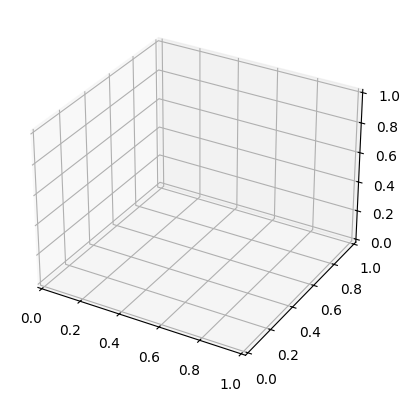

In [9]:
import matplotlib.pyplot as plt

def show_points_3d(X, labels):

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(X[:, 0], X[:, 1], X[:, 2])
    
    for i, label in enumerate(labels):
        ax.text(X[i, 0], X[i, 1], X[i, 2], label)
    
    ax.set_xlabel('Parent=VERB')
    ax.set_ylabel('Parent_rel=advmod')
    ax.set_zlabel('Child=NOUN')
    
    plt.show()

show_points_3d(X, df['lemma'])

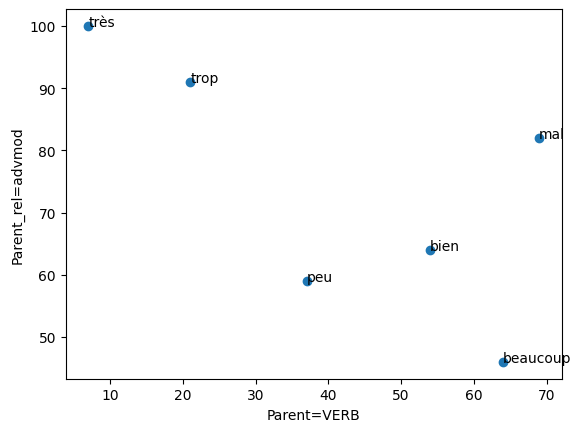

In [10]:
import matplotlib.pyplot as plt

def show_points_2d(X, labels):
    fig, ax = plt.subplots()
    ax.scatter(X[:, 0], X[:, 1])

    for i, label in enumerate(labels):
        ax.text(X[i, 0], X[i, 1], label)

    ax.set_xlabel('Parent=VERB')
    ax.set_ylabel('Parent_rel=advmod')

    plt.show()

show_points_2d(X, df['lemma'])

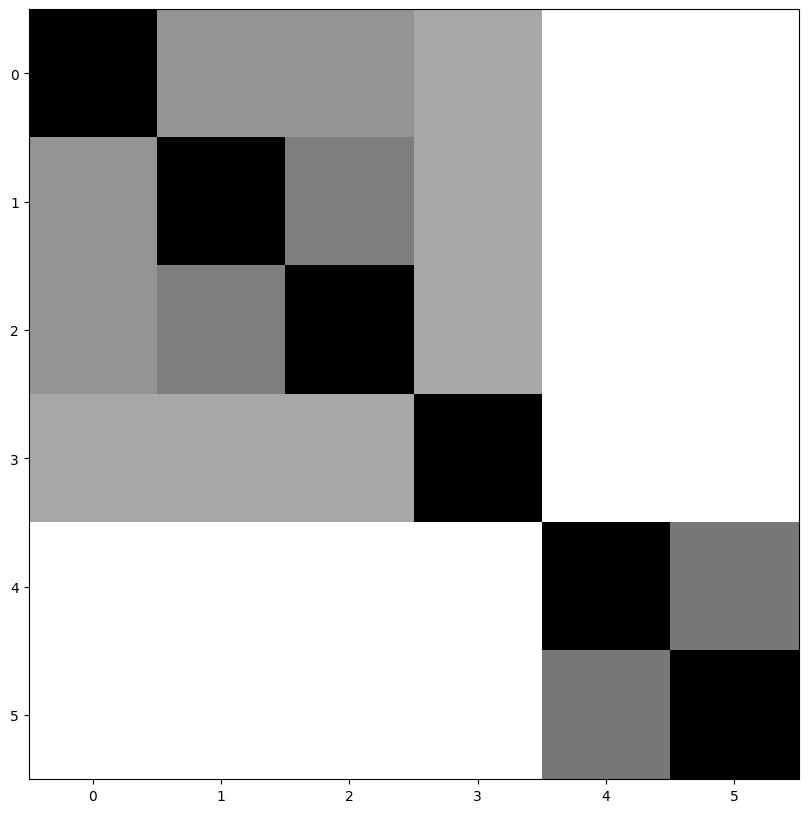

In [14]:
from pyclustertend import ivat
ivat(X)

In [20]:
from pyclustertend import hopkins
hopkins(X,2)

0.8174697359057471

In [ ]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster

# Compute the distance matrix
euclidean_distance_matrix = pdist(X, metric='euclidean')
cos_distance_matrix = pdist(X, metric='cosine')

# Perform hierarchical clustering
linked = linkage(euclidean_distance_matrix, method='ward')


In [25]:
X

array([[ 54,  64],
       [ 69,  82],
       [ 64,  46],
       [ 37,  59],
       [  7, 100],
       [ 21,  91]])

[[ 0.  23.4 20.6 17.7 59.2 42.6]
 [23.4  0.  36.3 39.4 64.6 48.8]
 [20.6 36.3  0.  30.  78.5 62.2]
 [17.7 39.4 30.   0.  50.8 35.8]
 [59.2 64.6 78.5 50.8  0.  16.6]
 [42.6 48.8 62.2 35.8 16.6  0. ]]


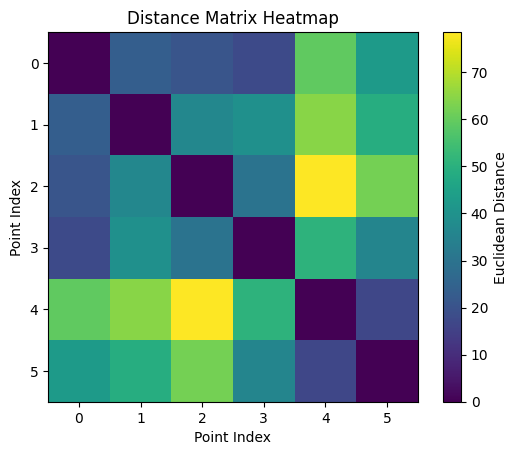

In [27]:
import numpy as np
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt

X = np.array([
    [54, 64],
    [69, 82],
    [64, 46],
    [37, 59],
    [7, 100],
    [21, 91]
])

# Compute the Euclidean distance matrix
dist_mat = distance_matrix(X, X)
print(np.round(dist_mat, 1))

# Visualize as a heatmap
plt.imshow(dist_mat, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Euclidean Distance')
plt.title('Distance Matrix Heatmap')
plt.xlabel('Point Index')
plt.ylabel('Point Index')
plt.show()

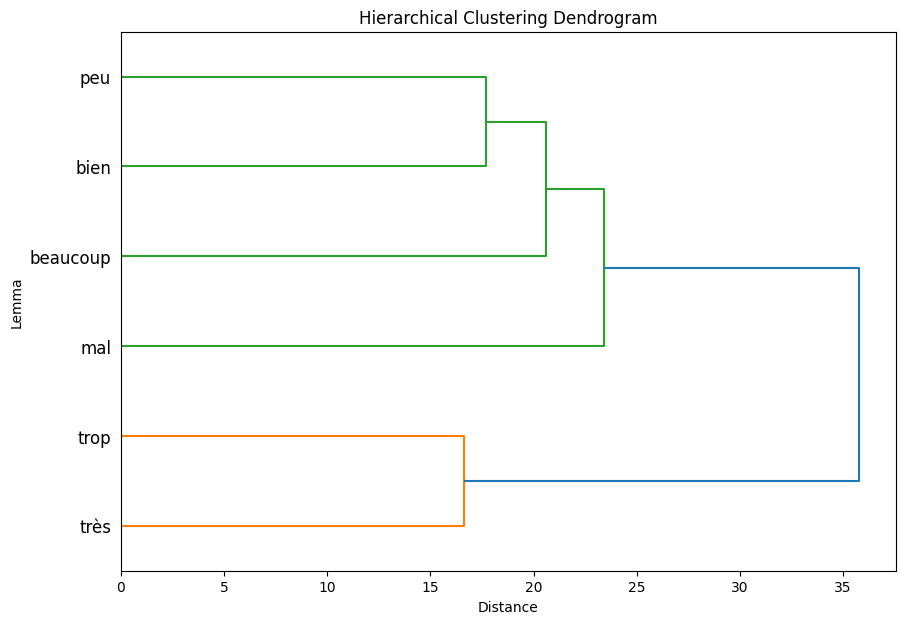

In [34]:
distance_matrix = pdist(X, metric='euclidean')
linked = linkage(distance_matrix, method='single')
from scipy.cluster.hierarchy import dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='right', labels=df['lemma'].values)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Distance')
plt.ylabel('Lemma')
plt.show()

In [69]:
# apply kmeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
cluster_assignments = kmeans.labels_

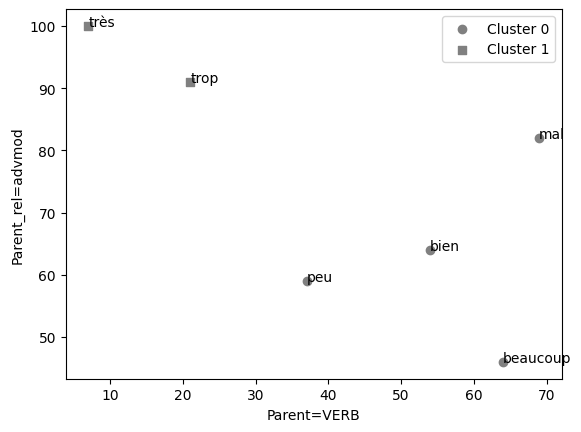

In [ ]:
import matplotlib.pyplot as plt

def show_points_2d(X, labels, cluster_assignments):
    fig, ax = plt.subplots()
    # Define a list of marker shapes for clusters
    markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']  # Add more if you have more clusters

    for cluster in np.unique(cluster_assignments):
        idx = cluster_assignments == cluster
        marker = markers[cluster % len(markers)]  # Cycle through markers if more clusters than markers
        ax.scatter(X[idx, 0], X[idx, 1], marker=marker, color='gray', s=100, label=f'Cluster {cluster}')
        for i in np.where(idx)[0]:
            ax.text(X[i, 0], X[i, 1], labels[i])

    ax.set_xlabel('Parent=VERB')
    ax.set_ylabel('Parent_rel=advmod')
    ax.legend()
    plt.show()


show_points_2d(X, df['lemma'], cluster_assignments)

In [62]:
from minisom import MiniSom

lemma = ['bien', 'mal', 'beaucoup', 'peu', 'très', 'trop']
X_normalized = X
som = MiniSom(x=4, y=4, input_len=X.shape[1], sigma=5.0, learning_rate=0.05)
som.random_weights_init(X_normalized)

# Train the SOM
som.train_random(X_normalized, num_iteration=10000)

# Map each data point to its winning neuron
winning_neurons = np.array([som.winner(x) for x in X_normalized])

# Group data points by their winning neurons
clusters = {}
for i, neuron in enumerate(winning_neurons):
    neuron = tuple(neuron)  # Convert numpy array to tuple
    if neuron not in clusters:
        clusters[neuron] = []
    clusters[neuron].append(i)

# # Map cluster indices back to original data (adv keys)
clustered_data = {}
for neuron, indices in clusters.items():

    clustered_data[neuron] = [lemma[i] for i in indices]

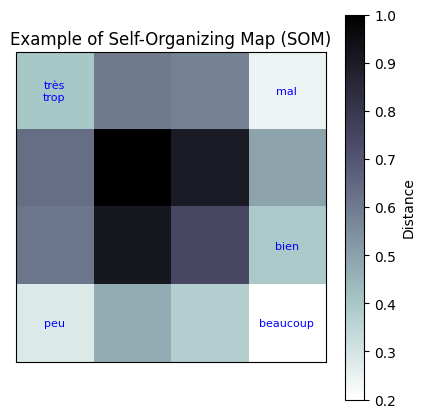

In [67]:
plt.figure(figsize=(5, 5))

# Iterate over the clusters and plot the adverbs in each neuron
for neuron, indices in clusters.items():
    # Extract the adverbs corresponding to the indices
    adverbs = [lemma[i] for i in indices]  # Extract the adverb part from the tuple
    adverbs_text = "\n".join(adverbs)  # Join adverbs with line breaks for better readability
    
    # Plot the adverbs in the corresponding neuron square
    plt.text(neuron[0], neuron[1], adverbs_text, 
             color='blue', fontsize=8, ha='center', va='center', wrap=True)

# Add the distance map as the background
plt.title("Example of Self-Organizing Map (SOM)")
plt.yticks([])
plt.xticks([])
plt.imshow(som.distance_map(), cmap='bone_r')  # Distance map as background
plt.colorbar(label='Distance')
plt.show()

In [33]:
linked

array([[ 4.        ,  5.        , 16.64331698,  2.        ],
       [ 0.        ,  3.        , 17.72004515,  2.        ],
       [ 2.        ,  7.        , 20.59126028,  3.        ],
       [ 1.        ,  8.        , 23.43074903,  4.        ],
       [ 6.        ,  9.        , 35.77708764,  6.        ]])

In [23]:
euclidean_distance_matrix

array([23.43074903, 20.59126028, 17.72004515, 59.20304046, 42.63801121,
       36.34556369, 39.40812099, 64.56004957, 48.83646179, 29.96664813,
       78.51751397, 62.24146528, 50.80354318, 35.77708764, 16.64331698])

In [24]:
cos_distance_matrix

array([8.94045834e-07, 3.02868238e-02, 9.88655822e-03, 1.92543402e-01,
       1.10275746e-01, 3.06142960e-02, 9.69987650e-03, 1.91755276e-01,
       1.09666114e-01, 7.41341454e-02, 3.61086302e-01, 2.48720797e-01,
       1.17777943e-01, 5.50395210e-02, 1.22855820e-02])